# CrisisNLP_R1

---

## A. Original

### CrisisNLP_labeled_data_crowdflower

- In this folder, each dataset contains more than 1,500 labeled tweets
- We used paid workers from the CrowdFlower crowdsourcing platform for the labeling
- At least three different workers were required to agree on a label to finalize a tweet label
- No worker was allowed to perform more than 200 tasks
- Detailed crowdsourcing tasks description is provided inside each folder
- No browsing to URLs in tweets.

#### Category---description:

1. Injured or dead people---Reports of casualties and/or injured people due to the crisis
2. Missing, trapped, or found people---Reports and/or questions about missing or found people
3. Displaced people and evacuations---People who have relocated due to the crisis, even for a short time (includes evacuations)
4. Infrastructure and utilities damage---Reports of damaged buildings, roads, bridges, or utilities/services interrupted or restored
5. Donation needs or offers or volunteering services---Reports of urgent needs or donations of shelter and/or supplies such as food, water, clothing, money, medical supplies or blood; and volunteering services
6. Caution and advice---Reports of warnings issued or lifted, guidance and tips
7. Sympathy and emotional support---Prayers, thoughts, and emotional support
8. Other useful information---Other useful information that helps understand the situation
9. Not related or irrelevant---Unrelated to the situation or irrelevant 

### CrisisNLP_volunteers_labeled_data

- We used volunteers through the AIDR platform (http://aidr.qcri.org/) to label this data
- At least three different workers were required to agree on a label before a task is finalized
- Each folder contains crowdsourcing task details


#### Label---Description

* Informative---Contributes useful information enhancing situational awareness
* Personal only---Personal and only useful to a small circle of family/friends of the author
* Not related to crisis---Not related to the crisis

### Ref

Muhammad Imran, Prasenjit Mitra, Carlos Castillo: Twitter as a Lifeline: Human-annotated Twitter Corpora for NLP of Crisis-related Messages. In Proceedings of the 10th Language Resources and Evaluation Conference (LREC), pp. 1638-1643. May 2016, Portorož, Slovenia.

Muhammad Imran, Carlos Castillo, Ji Lucas, Patrick Meier, and Sarah Vieweg. AIDR: Artificial Intelligence for Disaster Response. In Proceedings of the 23th International Conference on World Wide Web (WWW) Companion, 2014. Seoul, Korea.


## B. Overview

In [20]:
from pathlib import Path
import os

import numpy as np
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

dataset_path = Path(os.getenv("DATASETS_PATH")) / 'CrisisNLP_R1'

### B.1 CrisisNLP_labeled_data_crowdflower
#### B.1.1. Data Loading and Structural handling

In [21]:
events_CF = {
    '2013_Pakistan_eq': {
        'country': 'Pakistan',
        'event_type': 'earthquake',
        'event_name': '2013 Pakistan Earthquake',
        'year': 2013,
    },
    '2014_California_Earthquake': {
        'country': 'US',
        'event_type': 'earthquake',
        'event_name': '2014 California Earthquake',
        'year': 2014,
    },
    '2014_Chile_Earthquake_en': {
        'country': 'Chile',
        'event_type': 'earthquake',
        'event_name': '2014 Chile Earthquake',
        'year': 2014,
    },
    '2014_Hurricane_Odile_Mexico_en': {
        'country': 'Mexico',
        'event_type': 'storm',
        'event_name': '2014 Hurricane Odile Mexico',
        'year': 2014,
    },
    '2014_India_floods': {
        'country': 'India',
        'event_type': 'flood',
        'event_name': '2014 India Floods',
        'year': 2014,
    },
    '2014_Pakistan_floods': {
        'country': 'Pakistan',
        'event_type': 'flood',
        'event_name': '2014 Pakistan Floods',
        'year': 2014,
    },
    '2014_Philippines_Typhoon_Hagupit_en': {
        'country': 'Philippines',
        'event_type': 'storm',
        'event_name': '2014 Philippines Typhoon Hagupit',
        'year': 2014,
    },
    '2015_Cyclone_Pam_en': {
        'country': 'Vanuatu',
        'event_type': 'storm',
        'event_name': '2015 Cyclone Pam',
        'year': 2015,
    },
    '2015_Nepal_Earthquake_en': {
        'country': 'Nepal',
        'event_type': 'earthquake',
        'event_name': '2015 Nepal Earthquake',
        'year': 2015,
    },
    # # Skip because not in English
    # 2014_ebola_cf
    # 2014_Chile_Earthquake_cl
    
    # # Skip because not natural disaster
    # 2014_Middle_East_Respiratory_Syndrome_en
}

In [22]:
base_dir = dataset_path / 'CrisisNLP_labeled_data_crowdflower'
all_files = sorted(base_dir.rglob('*.tsv'))

dfs = []
for file in all_files:
    parent_name = file.parent.name
    if parent_name not in events_CF:
        print(f'Skipping: {parent_name}')
        continue
    data = events_CF[parent_name]
    df = pd.read_csv(file, sep='\t', encoding='utf_8')
    df['tweet_id'] = df['tweet_id'].str.strip("'").astype('int64')
    df['event_type'] = data['event_type']
    df['event_name'] = data['event_name']
    df['country'] = data['country']
    df['year'] = data['year']
    df['dataset'] = 'CrisisNLP_R1_CF'
    df['meta'] = df.apply(
        lambda x: {
            'file_name': file.name,
            'sub_dataset': 'Crowdflower'
            },
        axis=1)
    dfs.append(df)

df_CF = pd.concat(dfs, ignore_index=True)

Skipping: 2014_Chile_Earthquake_cl
Skipping: 2014_Middle_East_Respiratory_Syndrome_en
Skipping: 2014_ebola_cf


In [23]:
print(df_CF['label'].value_counts())

label
other_useful_information                             5165
donation_needs_or_offers_or_volunteering_services    2452
injured_or_dead_people                               2321
not_related_or_irrelevant                            2230
sympathy_and_emotional_support                       1887
infrastructure_and_utilities_damage                  1394
caution_and_advice                                   1011
displaced_people_and_evacuations                      547
missing_trapped_or_found_people                       375
Name: count, dtype: int64


In [24]:
df_CF["relevant"] = df_CF["label"].apply(lambda x: False if x == "not_related_or_irrelevant" else True)

df_CF['original_relevant_label'] = np.nan
df_CF["humanitarian_label"] = df_CF["label"]

df_CF.rename(columns={
    'label': 'original_humanitarian_label'
}, inplace=True)

### B.2 CrisisNLP_volunteers_labeled_data

#### B.2.1. Data Loading and Structural handling

In [25]:
events_VO = {
    '2014_California_Earthquake': {
        'country' : 'US',
        'event_type' : 'earthquake',
        'event_name' : '2014 California Earthquake',
        'year' : 2014,
    },
    '2014_Chile_Earthquake_en': {
        'country' : 'Chile',
        'event_type' : 'earthquake',
        'event_name' : '2014 Chile Earthquake',
        'year' : 2014,
    },
    '2014_Hurricane_Odile_Mexico_en': {
        'country' : 'Mexico',
        'event_type' : 'storm',
        'event_name' : '2014 Hurricane Odile Mexico',
        'year' : 2014,
    },
    '2014_Iceland_Volcano_en': {
        'country' : 'Iceland',
        'event_type' : 'volcano',
        'event_name' : '2014 Iceland Volcano',
        'year' : 2014,
    },
    '2014_Philippines_Typhoon_Hagupit_en': {
        'country' : 'Philippines',
        'event_type' : 'storm',
        'event_name' : '2014 Philippines Typhoon Hagupit',
        'year' : 2014,
    },
    '2015_Cyclone_Pam_en': {
        'country' : 'Vanuatu',
        'event_type' : 'storm',
        'event_name' : '2015 Cyclone Pam',
        'year' : 2015,
    },
    '2015_Nepal_Earthquake_en': {
        'country' : 'Nepal',
        'event_type' : 'earthquake',
        'event_name' : '2015 Nepal Earthquake',
        'year' : 2015,
    },
    'Landslides_Worldwide_en': {
        'country' : 'Worldwide',
        'event_type' : 'earthquake',
        'event_name' : 'Landslides Worldwide',
        'year' : -1,
    },
    # # Skip because not natural disaster
    # 2014_Malaysia_Airline_MH370_en
    # 2014_Middle_East_Respiratory_Syndrome_en

    # # Skip because not in English
    # Landslides_Worldwide_fr
    # Landslides_Worldwide_esp
    # 2014_Chile_Earthquake_cl
}

In [26]:
base_dir = dataset_path / 'CrisisNLP_volunteers_labeled_data'
all_files = sorted(base_dir.rglob('*.csv'))

meta_columns = ['file_name',
                'tweet_time', 'tweet_author', 'tweet_author_id', 'tweet_language',
                'tweet_lon', 'tweet_lat', 'tweet_url']

dfs = []
for file in all_files:
    parent_name = file.parent.name
    if parent_name not in events_VO:
        print(f'Skipping: {parent_name}')
        continue

    df = pd.read_csv(file, encoding='cp437')
    df.columns = df.columns.str.strip()
    data = events_VO[parent_name]
    df['tweet_id'] = df['tweet_id'].str.strip("'").astype('int64')
    df['event_type'] = data['event_type']
    df['event_name'] = data['event_name']
    df['country'] = data['country']
    df['year'] = data['year']
    df['file_name'] = file.name
    df['dataset'] = 'CrisisNLP_R1_VO'
    df['meta'] = df[meta_columns].to_dict(orient='records')

    df.drop(columns=meta_columns, inplace=True)
    dfs.append(df)

df_VO = pd.concat(dfs, ignore_index=True)

Skipping: 2014_Chile_Earthquake_cl
Skipping: 2014_Malaysia_Airline_MH370_en
Skipping: 2014_Middle_East_Respiratory_Syndrome_en
Skipping: Landslides_Worldwide_esp
Skipping: Landslides_Worldwide_fr


#### B.2.2. Cleaning and Preprocessing

**Language**

In [27]:
tweet_languages = df_VO['meta'].map(lambda meta: meta.get('tweet_language'))
print(tweet_languages.value_counts(dropna=False))

# Drop non-English tweets
df_VO = df_VO[tweet_languages == 'en'].reset_index(drop=True)

meta
en    24736
fr      448
es      222
it       54
Name: count, dtype: int64


**labels Mapping**

- Personal mapping based on paper description and label names for consistency with CF dataset

In [28]:
print(df_VO['label'].value_counts())

label
Not Informative                        6742
Not Relevant                           6279
Not physical landslide                 3236
Other Relevant Information             2906
Response Efforts                        994
Other relevant information              556
Sympathy and emotional support          545
Physical landslide                      531
Not related or irrelevant               477
Infrastructure Damage                   426
Humanitarian Aid Provided               323
Not related to crisis                   222
Other useful information                214
Caution and advice                      190
Informative                             161
Infrastructure and utilities            148
Injured or dead people                  115
Urgent Needs                            108
Volunteer or professional services       76
Requests for Help/Needs                  71
Personal updates, sympathy, support      66
Money                                    63
Injured and dead          

In [29]:
label_mapping = {
    "Other Relevant Information": "other_useful_information",
    "Other relevant information": "other_useful_information",
    "Other useful information": "other_useful_information",
    "Informative": "other_useful_information",
    "Personal updates": "other_useful_information",
    "Other relevant": "other_useful_information",
    "Animal management": "other_useful_information",
    "Non-government": "other_useful_information",
    "Traditional media": "other_useful_information",
    "Physical landslide": "other_useful_information",
    "Volunteer or professional services": "donation_needs_or_offers_or_volunteering_services",
    "Money": "donation_needs_or_offers_or_volunteering_services",
    "Humanitarian Aid Provided": "donation_needs_or_offers_or_volunteering_services",
    "Shelter and supplies": "donation_needs_or_offers_or_volunteering_services",
    "Donations of money": "donation_needs_or_offers_or_volunteering_services",
    "Needs of those affected": "donation_needs_or_offers_or_volunteering_services",
    "Injured or dead people": "injured_or_dead_people",
    "Urgent Needs": "injured_or_dead_people",
    "Requests for Help/Needs": "injured_or_dead_people",
    "Injured and dead": "injured_or_dead_people",
    "Sympathy and emotional support": "sympathy_and_emotional_support",
    "Personal updates, sympathy, support": "sympathy_and_emotional_support",
    "Infrastructure Damage": "infrastructure_and_utilities_damage",
    "Infrastructure and utilities": "infrastructure_and_utilities_damage",
    "Infrastructure": "infrastructure_and_utilities_damage",
    "Infrastructure damage": "infrastructure_and_utilities_damage",
    "Caution and advice": "caution_and_advice",
    "Response Efforts": "displaced_people_and_evacuations",
    "Displaced people": "displaced_people_and_evacuations",
    "Response efforts": "displaced_people_and_evacuations",
    "Missing, trapped, or found people": "missing_trapped_or_found_people",
    # Not relevant labels
    "Not related or irrelevant": "not_related_or_irrelevant",
    "Not Informative": "not_related_or_irrelevant",
    "Not Relevant": "not_related_or_irrelevant",
    "Not related to crisis": "not_related_or_irrelevant",
    "Not informative": "not_related_or_irrelevant",
    "Not relevant": "not_related_or_irrelevant",
    "Not physical landslide": "not_related_or_irrelevant",
}

df_VO['humanitarian_label'] = df_VO['label'].map(label_mapping)
df_VO['relevant'] = df_VO['humanitarian_label'].apply(
    lambda x: False if x == "not_related_or_irrelevant" else True)
df_VO.rename(columns={'label': 'original_humanitarian_label'}, inplace=True)

df_VO["original_relevant_label"] = np.nan

### B.3 Merge `volunteers` and `crowdflower` and to one



In [30]:
df = pd.concat([df_VO, df_CF], ignore_index=False)
print(f'Total rows in original dataset: {len(df)}')
df.head()

Total rows in original dataset: 42118


,tweet_id,tweet_text,original_humanitarian_label,event_type,event_name,country,year,dataset,meta,humanitarian_label,relevant,original_relevant_label
0,503866345822244864,"σ_ USA 592 Earthquake Earthquake rattles, does...",Infrastructure and utilities,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1_VO,{'file_name': '2014_California_Earthquake.csv'...,infrastructure_and_utilities_damage,True,NaN
1,503866373961809920,ë█ó ë█ó Earthquake #Earthquake California Eart...,Other relevant information,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1_VO,{'file_name': '2014_California_Earthquake.csv'...,other_useful_information,True,NaN
2,503866427322159104,WCVB Boston: California quake: Recovering afte...,Other relevant information,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1_VO,{'file_name': '2014_California_Earthquake.csv'...,other_useful_information,True,NaN
3,503866453280317440,I don't know. CALIFORNIA. if u had a winery th...,Not related or irrelevant,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1_VO,{'file_name': '2014_California_Earthquake.csv'...,not_related_or_irrelevant,False,NaN
4,503866484461170688,"NOW: Possible #Timmies, #BurgerKing merger, #O...",Not related or irrelevant,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1_VO,{'file_name': '2014_California_Earthquake.csv'...,not_related_or_irrelevant,False,NaN


#### Remove duplicated

**Remove duplicate tweets of df_VO from df_CF**

In [31]:
df_db_dup = df[df.duplicated(subset=["tweet_id"], keep=False)]

CF_ids = set(df_db_dup[df_db_dup['dataset'] == 'CrisisNLP_R1_CF']['tweet_id'])
VO_ids = set(df_db_dup[df_db_dup['dataset'] == 'CrisisNLP_R1_VO']['tweet_id'])

print(f'Number of unique tweet ids in CF: {len(CF_ids)}')
print(f'Number of unique tweet ids in VO: {len(VO_ids)}')
redundant_ids = CF_ids.intersection(VO_ids)
print(f'Number of overlapping tweet ids: {len(redundant_ids)}')

df = df[~df['tweet_id'].isin(redundant_ids)].reset_index(drop=True)

Number of unique tweet ids in CF: 73
Number of unique tweet ids in VO: 84
Number of overlapping tweet ids: 73


**Clean for duplicates in the 'tweet_id' column**

Priority not related tweet

In [32]:
df_id_dup = df[df.duplicated(subset=["tweet_id"], keep='last')].sort_values(["tweet_id", "relevant"])
print(f'Total duplicate rows: {len(df_id_dup)}')
print(df_id_dup.head(10))

df.drop(df_id_dup.index, inplace=True)

Total duplicate rows: 11
                tweet_id                                         tweet_text  \
1620  541249463734370304               Power is out again in Banawa #RubyPH   
1960  541316404847591424  Typhoon #Hagupit "#Ruby" #Philippines http://t...   
2243  541378350053208064  Praying for everyones safety. ç__Fç__Fç__F #Ru...   
2369  541391184216592385  True! #PrayHarderAndBeSafe #RubyPh http://t.co...   
3063  541455987543379968  http://t.co/hICUn1n1c3 Prayers for my Cousin J...   
3170  541460791589748736  Bed weather is bed weather #RubyPH ç__8ç__4ç_ó...   
3199  541462559182700544  @UNDP:ë█╧@abcnews:At least two dead in #borong...   
3572  541483446133350401  #RubyPH overtake power lines as well, not one ...   
3830  541498918375141376  "@TagaLPU: #WalangPasok December 8, 2014 ALL L...   
4037  541513820598853634  I guess #hagupit can't beat ondoy or yolanda #...   

     original_humanitarian_label event_type                        event_name  \
1620       Infrastructur

**Clean for duplicates in the 'tweet_text' column**

Priority not related tweet

In [33]:
df_txt_dup = df[df.duplicated(subset=["tweet_text"], keep=False)].sort_values([ "relevant"], ascending=False)

print(f"Number of duplicate tweets: {len(df_txt_dup)}")
df_txt_dup.head(10)

# Remove duplicates
df.drop(df_txt_dup.index, inplace=True)

Number of duplicate tweets: 527


#### Verifying

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41434 entries, 0 to 41971
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tweet_id                     41434 non-null  int64  
 1   tweet_text                   41434 non-null  object 
 2   original_humanitarian_label  41434 non-null  object 
 3   event_type                   41434 non-null  object 
 4   event_name                   41434 non-null  object 
 5   country                      41434 non-null  object 
 6   year                         41434 non-null  int64  
 7   dataset                      41434 non-null  object 
 8   meta                         41434 non-null  object 
 9   humanitarian_label           41434 non-null  object 
 10  relevant                     41434 non-null  bool   
 11  original_relevant_label      0 non-null      float64
dtypes: bool(1), float64(1), int64(2), object(8)
memory usage: 3.8+ MB


In [35]:
df.describe(include='all')

,tweet_id,tweet_text,original_humanitarian_label,event_type,event_name,country,year,dataset,meta,humanitarian_label,relevant,original_relevant_label
count,4.143400e+04,41434,41434,41434,41434,41434,41434.000000,41434,41434,41434,41434,0.0
unique,NaN,41434,46,4,11,10,NaN,2,24146,9,2,NaN
top,NaN,"σ_ USA 592 Earthquake Earthquake rattles, does...",Not Informative,earthquake,2015 Nepal Earthquake,Nepal,NaN,CrisisNLP_R1_VO,{'file_name': '2015_Nepal_Earthquake_en_CF_lab...,not_related_or_irrelevant,True,NaN
freq,NaN,1,6515,22140,12347,12347,NaN,24137,2985,18799,22635,NaN
mean,5.421252e+17,NaN,NaN,NaN,NaN,NaN,1835.059372,NaN,NaN,NaN,NaN,NaN
std,5.285352e+16,NaN,NaN,NaN,NaN,NaN,573.750200,NaN,NaN,NaN,NaN,NaN
min,3.828135e+17,NaN,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,NaN
25%,5.110447e+17,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN,NaN,NaN,NaN,NaN
50%,5.419265e+17,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN,NaN,NaN,NaN,NaN
75%,5.921641e+17,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='relevant'>

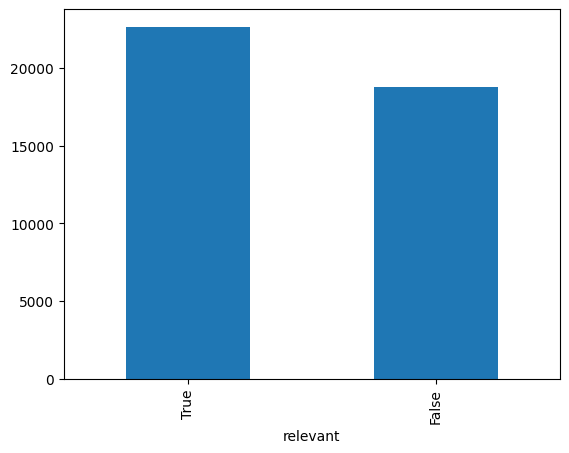

In [36]:
df['relevant'].value_counts().plot(kind='bar')

<Axes: xlabel='humanitarian_label'>

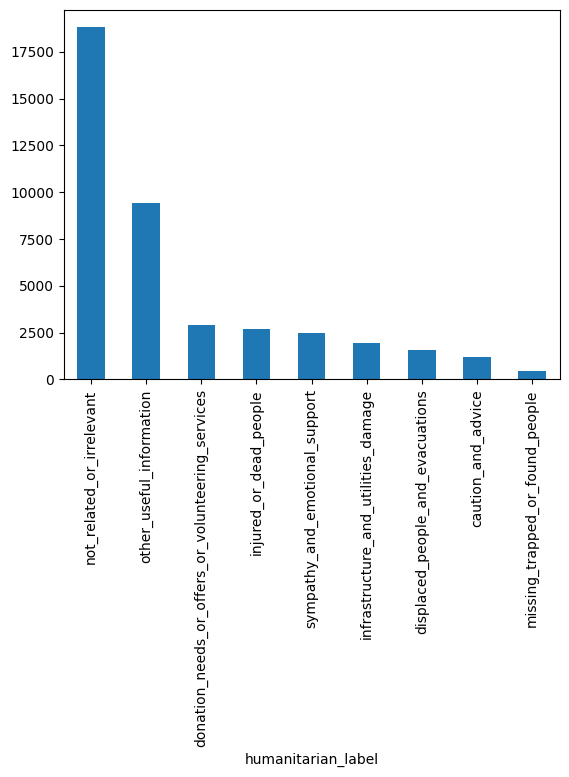

In [37]:
df['humanitarian_label'].value_counts().plot(kind='bar')

<Axes: xlabel='event_type'>

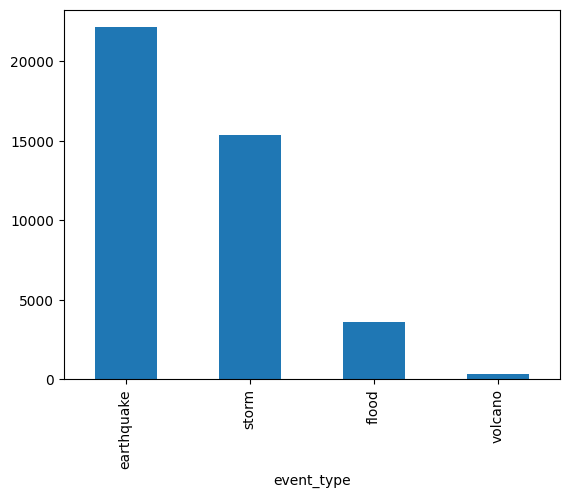

In [38]:
df['event_type'].value_counts().plot(kind='bar')